# Data Jobs - ML Pipeline v4
Target: `job_title_short` | LightGBM + MLflow Tracking + Model Saving

In [15]:
import pandas as pd
import numpy as np
import ast
import os
%pip install joblib
import matplotlib.pyplot as plt
from collections import Counter

import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)

from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)


Note: you may need to restart the kernel to use updated packages.


## 1. Load Data

In [16]:

data = pd.read_csv('C:/Users/Rayen/Downloads/dataset/dataset/data_jobs_normalized.csv')

print(f'Shape: {data.shape}')
data.head(3)

Shape: (785741, 17)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


In [17]:
data.isnull().sum()

job_title_short               0
job_title                     1
job_location               1045
job_via                       8
job_schedule_type         12667
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                  49
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                 18
job_skills               117037
job_type_skills          117037
dtype: int64

## 2. Clean & Feature Engineering

In [18]:
df = data.copy()

df = df.drop(columns=['salary_hour_avg', 'salary_year_avg', 'salary_rate'])

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['posted_year']  = df['job_posted_date'].dt.year
df['posted_month'] = df['job_posted_date'].dt.month
df['posted_day']   = df['job_posted_date'].dt.day
df = df.drop(columns=['job_posted_date'])

df['job_location'] = df['job_location'].fillna(df['search_location'])
df['job_country']  = df['job_country'].fillna(
    df['search_location'].apply(lambda x: x.split(',')[-1].strip() if isinstance(x, str) else x)
)
df['job_title'] = df['job_title'].fillna(df['job_title_short'])
df['job_via']   = df['job_via'].str.replace('via ', '', case=False, regex=True)

for col in ['job_via', 'job_schedule_type', 'company_name']:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in ['job_skills', 'job_type_skills']:
    mapping = (
        df.groupby('job_title_short')[col]
        .apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
        .to_dict()
    )
    df[col] = df[col].fillna(df['job_title_short'].map(mapping))

print('Nulls remaining:')
print(df.isna().sum()[df.isna().sum() > 0])


Nulls remaining:
Series([], dtype: int64)


## 3. Parse Skills

In [19]:
def safe_parse_list(x):
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return []
    return []

def safe_parse_dict(x):
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return x if isinstance(x, dict) else {}

df['job_skills_list']      = df['job_skills'].apply(safe_parse_list)
df['job_type_skills_dict'] = df['job_type_skills'].apply(safe_parse_dict)
df['skill_categories']     = df['job_type_skills_dict'].apply(lambda x: list(x.keys()))

def count_skills_by_category(d):
    return {f'n_{k}': len(v) for k, v in d.items()} if isinstance(d, dict) else {}

skill_counts_df = pd.DataFrame(
    df['job_type_skills_dict'].apply(count_skills_by_category).tolist()
).fillna(0).astype(np.int8)
skill_counts_df.index = df.index

df['num_skills']           = df['job_skills_list'].apply(len)
df['num_skill_categories'] = df['skill_categories'].apply(len)

df.head()


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_no_degree_mention,job_health_insurance,job_country,company_name,job_skills,job_type_skills,posted_year,posted_month,posted_day,job_skills_list,job_type_skills_dict,skill_categories,num_skills,num_skill_categories
0,Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",Work Nearby,Full-time,0,"Texas, United States",0,0,United States,Boehringer Ingelheim,['sql'],{'programming': ['sql']},2023,6,16,[sql],{'programming': ['sql']},[programming],1,1
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",BeBee México,Full-time,0,Mexico,0,0,Mexico,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",2023,1,14,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...","[analyst_tools, programming]",6,2
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",LinkedIn,Full-time,0,Germany,0,0,Germany,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",2023,10,10,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...","[analyst_tools, cloud, libraries, other, progr...",9,5
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",Diversity.com,Full-time,0,"Texas, United States",1,0,United States,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",2023,7,4,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...","[cloud, libraries, programming]",8,3
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",Clearance Jobs,Full-time,0,Sudan,0,0,Sudan,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",2023,8,7,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...","[cloud, other, programming]",9,3


## 4. Vectorize Skills — Top 200

In [20]:
all_skills_flat = [s for sublist in df['job_skills_list'] for s in sublist]
top_skills = [s for s, _ in Counter(all_skills_flat).most_common(200)]

mlb_skills = MultiLabelBinarizer(classes=top_skills)
skills_df = pd.DataFrame(
    mlb_skills.fit_transform(df['job_skills_list']).astype(np.int8),
    columns=[f'skill_{s}' for s in top_skills],
    index=df.index
)

mlb_cat = MultiLabelBinarizer()
cat_df = pd.DataFrame(
    mlb_cat.fit_transform(df['skill_categories']).astype(np.int8),
    columns=[f'cat_{c}' for c in mlb_cat.classes_],
    index=df.index
)

print(f'Skills: {skills_df.shape} | Categories: {cat_df.shape}')


c:\Users\Rayen\Desktop\ProjetPython2\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['angular.js', 'asp.netcore', 'blazor', 'capacitor', 'chainer', 'clickup', 'cordova', 'delphi', 'deno', 'dingtalk', 'dlib', 'ember.js', 'erlang', 'esquisse', 'f#', 'fastify', 'fedora', 'gatsby', 'google chat', 'gtx', 'homebrew', 'huggingface', 'ionic', 'kali', 'linode', 'lisp', 'mattermost', 'microsoft lists', 'mlpack', 'mlr', 'msaccess', 'nuix', 'nuxt.js', 'ocaml', 'ovh', 'pascal', 'play framework', 'qt', 'ringcentral', 'rocketchat', 'rubyon rails', 'shogun', 'sqlserver', 'suse', 'svelte', 'tidyr', 'visualbasic', 'wimi', 'workfront', 'wrike', 'wsl', 'xamarin'] will be ignored
  warnings.warn(


Skills: (785741, 200) | Categories: (785741, 10)


## 5. Country Frequency Encoding

In [21]:
country_freq = df['job_country'].value_counts(normalize=True)
df['country_freq_enc'] = df['job_country'].map(country_freq)


## 6. TF-IDF on Job Title

In [22]:
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1, 2), sublinear_tf=True)
title_tfidf_df = pd.DataFrame(
    tfidf.fit_transform(df['job_title'].astype(str)).toarray().astype(np.float32),
    columns=[f'title_{t}' for t in tfidf.get_feature_names_out()],
    index=df.index
)
print(f'TF-IDF: {title_tfidf_df.shape}')


TF-IDF: (785741, 200)


## 7. Encode Categoricals

In [23]:
ordinal_cols = ['job_via', 'job_schedule_type', 'job_location', 'search_location', 'company_name']
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[ordinal_cols] = oe.fit_transform(df[ordinal_cols].astype(str))


## 8. Build Final Feature Matrix

In [24]:
base_features = [
    'job_work_from_home', 'job_no_degree_mention', 'job_health_insurance',
    'posted_year', 'posted_month', 'posted_day',
    'num_skills', 'num_skill_categories', 'country_freq_enc'
] + ordinal_cols

#X = df[base_features]   # seulement les 14 colonnes

X = pd.concat([
   df[base_features].reset_index(drop=True),
    skills_df.reset_index(drop=True),
    cat_df.reset_index(drop=True),
    skill_counts_df.reset_index(drop=True),
    title_tfidf_df.reset_index(drop=True)
], axis=1)

le = LabelEncoder()
y = le.fit_transform(df['job_title_short'])

print(f'Feature matrix: {X.shape}')
print(f'Memory: {X.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Classes: {le.classes_}')


Feature matrix: (785741, 434)
Memory: 880.0 MB
Classes: ['Business Analyst' 'Cloud Engineer' 'Data Analyst' 'Data Engineer'
 'Data Scientist' 'ML Engineer' 'Software Engineer']


## 9. Train / Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')


Train: (628592, 434) | Test: (157149, 434)


## 10. MLflow — Configuration de l'expérience

In [26]:
# ─────────────────────────────────────────────────────────────
# Configuration MLflow
# mlflow server --host 0.0.0.0 --port 5000   (dans un terminal)
# Puis ouvrir : http://localhost:5000
# ─────────────────────────────────────────────────────────────

EXPERIMENT_NAME = "DataJobs_LightGBM_v4"

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Expérience MLflow : '{EXPERIMENT_NAME}'")


2026/03/09 14:07:59 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/09 14:07:59 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/09 14:07:59 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/09 14:07:59 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/09 14:07:59 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/09 14:07:59 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/09 14:07:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/09 14:07:59 INFO mlflow.store.db.utils: Updating database tables
2026/03/09 14:07:59 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/09 14:07:59 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/09 14:07:59 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/03/09 14:0

Expérience MLflow : 'DataJobs_LightGBM_v4'


## 11. Entraînement LightGBM + MLflow Tracking

In [28]:
!pip install joblib

In [30]:
import joblib
# Paramètres du modèle — pré-tuned, bon équilibre vitesse/performance
# Temps d'entraînement estimé : 2–4 minutes
MODEL_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)

with mlflow.start_run(run_name="LightGBM_v4") as run:

    # ── Build pipeline ──
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', LGBMClassifier(**MODEL_PARAMS))
    ])

    # ── Log paramètres dans MLflow ──
    mlflow.log_params(MODEL_PARAMS)
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("test_size",  X_test.shape[0])
    mlflow.log_param("n_features",  X_train.shape[1])
    mlflow.log_param("classes", list(le.classes_))

    # ── Entraînement ──
    print("🚀 Entraînement en cours...")
    pipeline.fit(X_train, y_train)
    print("✅ Training done!")

    # ── Évaluation ──
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    # ── Log métriques dans MLflow ──
    mlflow.log_metric("accuracy",  acc)
    mlflow.log_metric("f1_weighted", f1)
    mlflow.log_metric("f1_macro",  f1_macro)

    print(f"\n📊 Accuracy    : {acc:.4f}")
    print(f"📊 F1 Weighted : {f1:.4f}")
    print(f"📊 F1 Macro    : {f1_macro:.4f}")

    # ── Sauvegarder le modèle dans MLflow (avec signature) ──
    from mlflow.models.signature import infer_signature
    signature = infer_signature(X_train, pipeline.predict(X_train))

    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="model",
        signature=signature,
        registered_model_name="DataJobs_LightGBM"   # enregistre dans le Registry
    )
# ── Sauvegarder le modèle ──
    joblib.dump(pipeline, "../data/best_model_pipeline.pkl")
    joblib.dump(le,       "../data/label_encoder.pkl")

    # ── Sauvegarder les encodeurs pour l'API ──
    joblib.dump(oe,           "../data/ordinal_encoder.pkl")
    joblib.dump(mlb_skills,   "../data/mlb_skills.pkl")
    joblib.dump(mlb_cat,      "../data/mlb_cat.pkl")
    joblib.dump(tfidf,        "../data/tfidf.pkl")
    joblib.dump(top_skills,   "../data/top_skills.pkl")
    joblib.dump(country_freq, "../data/country_freq.pkl")

    mlflow.log_artifact("../data/best_model_pipeline.pkl", artifact_path="artifacts")
    mlflow.log_artifact("../data/label_encoder.pkl",       artifact_path="artifacts")
    mlflow.log_artifact("../data/ordinal_encoder.pkl",     artifact_path="artifacts")
    mlflow.log_artifact("../data/mlb_skills.pkl",          artifact_path="artifacts")
    mlflow.log_artifact("../data/mlb_cat.pkl",             artifact_path="artifacts")
    mlflow.log_artifact("../data/tfidf.pkl",               artifact_path="artifacts")
    mlflow.log_artifact("../data/top_skills.pkl",          artifact_path="artifacts")
    mlflow.log_artifact("../data/country_freq.pkl",        artifact_path="artifacts")

    RUN_ID = run.info.run_id
    print(f"\n🏷️  MLflow Run ID  : {RUN_ID}")
    print(f"📁 Modèles sauvés dans : data/")

🚀 Entraînement en cours...
✅ Training done!


c:\Users\Rayen\Desktop\ProjetPython2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 Accuracy    : 0.9467
📊 F1 Weighted : 0.9483
📊 F1 Macro    : 0.8832


c:\Users\Rayen\Desktop\ProjetPython2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Rayen\Desktop\ProjetPython2\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/09 14:29


🏷️  MLflow Run ID  : 48338f5d3b614e458800dc29396392b3
📁 Modèles sauvés dans : data/


## 12. Rapport de Classification

In [31]:
print(classification_report(y_test, y_pred, target_names=le.classes_))


                   precision    recall  f1-score   support

 Business Analyst       0.81      0.93      0.86      9813
   Cloud Engineer       0.61      0.83      0.70      2466
     Data Analyst       0.98      0.95      0.96     45058
    Data Engineer       0.99      0.97      0.98     46161
   Data Scientist       0.97      0.95      0.96     41849
      ML Engineer       0.79      0.91      0.84      2816
Software Engineer       0.86      0.90      0.88      8986

         accuracy                           0.95    157149
        macro avg       0.86      0.92      0.88    157149
     weighted avg       0.95      0.95      0.95    157149



## 13. Confusion Matrix

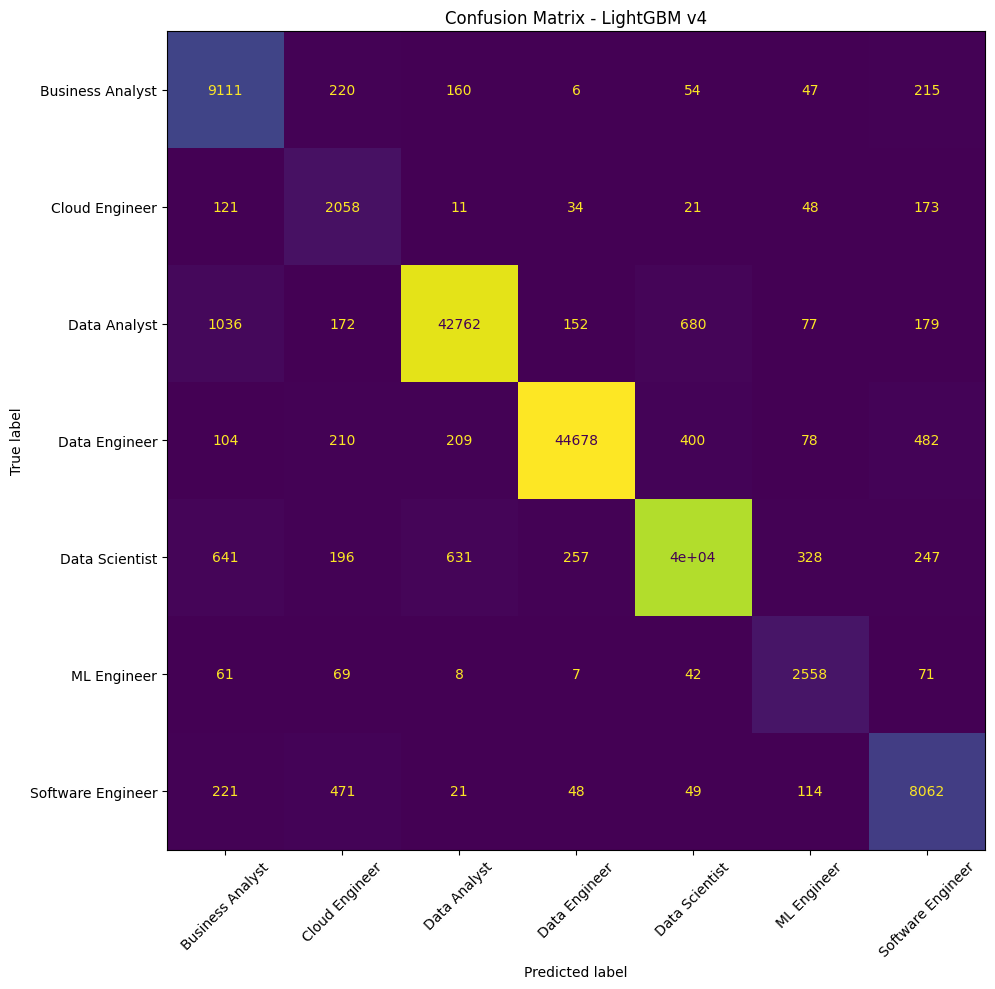

✅ Confusion matrix sauvée et loggée dans MLflow


In [32]:
os.makedirs('../data', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)
plt.title('Confusion Matrix - LightGBM v4')
plt.tight_layout()

cm_path = '../data/matrice de confusion.png'
plt.savefig(cm_path)
plt.show()
plt.close()

# Log dans MLflow
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_artifact(cm_path, artifact_path="plots")

print(f"✅ Confusion matrix sauvée et loggée dans MLflow")


## 14. Feature Importance (Top 40)

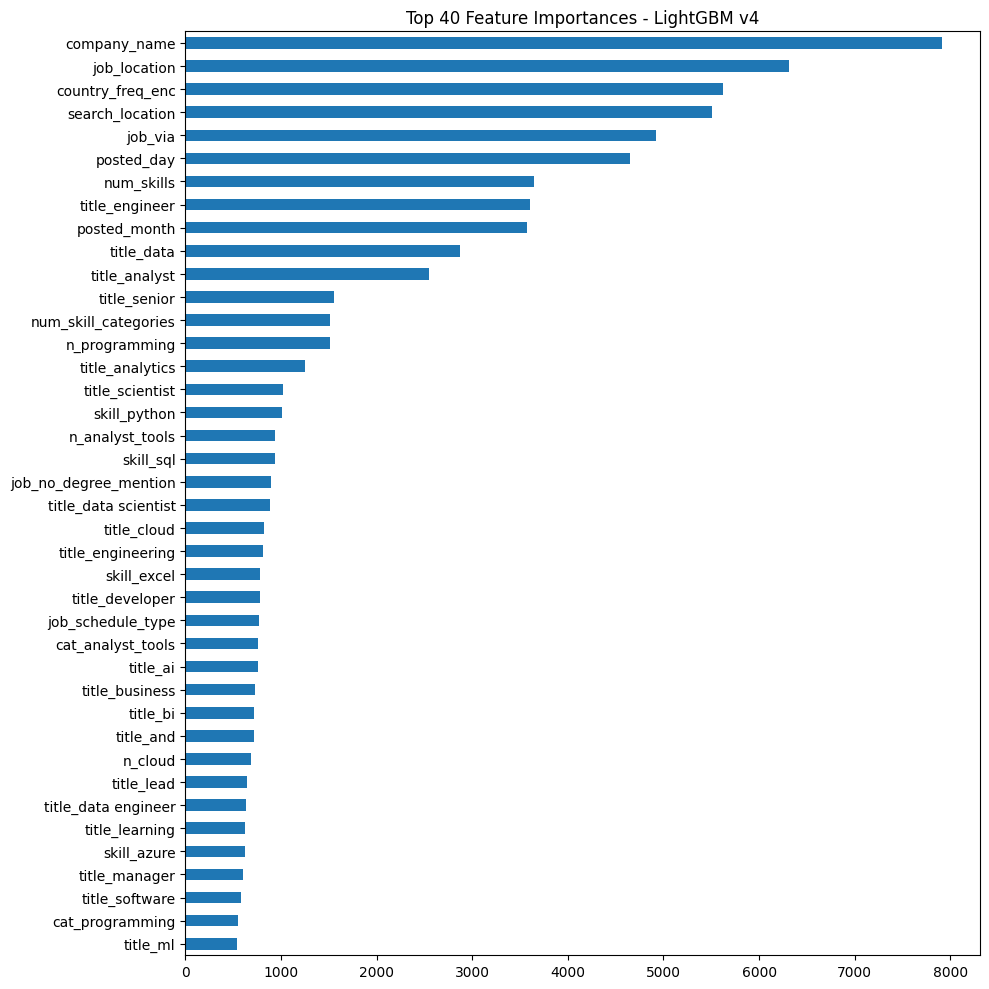

✅ Feature importance sauvée et loggée dans MLflow


In [33]:
clf = pipeline.named_steps['clf']
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(40)

plt.figure(figsize=(10, 10))
feat_imp.plot(kind='barh')
plt.title('Top 40 Feature Importances - LightGBM v4')
plt.gca().invert_yaxis()
plt.tight_layout()

fi_path = '../data/top40feature_importances.png'
plt.savefig(fi_path)
plt.show()

# Log dans MLflow
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_artifact(fi_path, artifact_path="plots")

print("✅ Feature importance sauvée et loggée dans MLflow")


## 15. Charger le Modèle depuis MLflow (inférence)

In [34]:
# ── Option A : charger depuis le Run ID ──
loaded_pipeline = mlflow.sklearn.load_model(f"runs:/{RUN_ID}/model")

# ── Option B : charger depuis le Registry (après promotion en Production) ──
# loaded_pipeline = mlflow.sklearn.load_model("models:/DataJobs_LightGBM/Production")

# ── Option C : charger depuis le .pkl local ──
# loaded_pipeline = joblib.load("models/pipeline_lgbm.pkl")

# Test de prédiction
sample = X_test.iloc[:5]
preds  = loaded_pipeline.predict(sample)
print("Prédictions (encodées) :", preds)
print("Prédictions (labels)   :", le.inverse_transform(preds))


c:\Users\Rayen\Desktop\ProjetPython2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Prédictions (encodées) : [4 3 3 4 4]
Prédictions (labels)   : ['Data Scientist' 'Data Engineer' 'Data Engineer' 'Data Scientist'
 'Data Scientist']


## 16. Résumé des fichiers sauvegardés

In [35]:
print("=== Fichiers modèles sauvegardés ===")
for f in os.listdir("models"):
    path = os.path.join("models", f)
    size = os.path.getsize(path) / 1e6
    print(f"  {f:<30} {size:.2f} MB")

print(f"\n=== MLflow Run ===")
print(f"  Run ID     : {RUN_ID}")
print(f"  Expérience : {EXPERIMENT_NAME}")


=== Fichiers modèles sauvegardés ===


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'models'